# DecipherATAC — Benchmark Results
Run `python -m benchmarks.run_benchmark` first to generate `benchmarks/results/latest.json`.

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.optimize import linear_sum_assignment

# ── Load results ──────────────────────────────────────────────────────────────
with open('results/latest.json') as f:
    R = json.load(f)

sweep      = R['sweep']           # list of dicts
mofa       = R['mofa']            # {'score': float, 'n_confounders': int}
sanity     = R['sanity_check']
default_s  = R['default_sim']

N_CONF_LEVELS = sorted(set(s['n_confounders'] for s in sweep))
SEEDS         = sorted(set(s['seed'] for s in sweep))

# ── Colour palette ────────────────────────────────────────────────────────────
C = {
    'std':  '#6C8EBF',
    'atac': '#E07B54',
    'mofa': '#7DB87D',
    'bg':   '#F7F5F2',
    'grid': '#E8E4DF',
    'text': '#2C2C2C',
}

plt.rcParams.update({
    'font.family': 'serif', 'font.size': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.facecolor': C['bg'], 'figure.facecolor': 'white',
    'axes.grid': True, 'grid.color': C['grid'], 'grid.linewidth': 0.8,
})

# ── Helper: compute stats per confounder level ────────────────────────────────
def sweep_stats():
    stats = {}
    for n in N_CONF_LEVELS:
        rows = [s for s in sweep if s['n_confounders'] == n]
        sv = [r['std_score']  for r in rows]
        av = [r['atac_score'] for r in rows]
        stats[n] = {
            'std_mean':  np.mean(sv), 'std_err':  np.std(sv, ddof=1)/np.sqrt(len(sv)),
            'atac_mean': np.mean(av), 'atac_err': np.std(av, ddof=1)/np.sqrt(len(av)),
            'std_vals': sv, 'atac_vals': av,
        }
    return stats

stats  = sweep_stats()
deltas = {n: [r['atac_score'] - r['std_score']
              for r in sweep if r['n_confounders'] == n]
          for n in N_CONF_LEVELS}

print('Loaded results from', R['timestamp'])
print(f"Sweep: {len(sweep)} runs across {N_CONF_LEVELS} confounder levels, seeds {SEEDS}")
if mofa['score'] is not None:
    print(f"MOFA+ score: {mofa['score']:.3f} (measured at n_confounders={mofa['n_confounders']})")

Loaded results from 2026-03-09T02:02:43.088684
Sweep: 12 runs across [0, 100, 250, 500] confounder levels, seeds [7, 42, 123]
MOFA+ score: 0.280 (measured at n_confounders=500)


## Panel A — Interpretability vs. confounder burden

FileNotFoundError: [Errno 2] No such file or directory: 'benchmarks/results/panel_A_sweep.png'

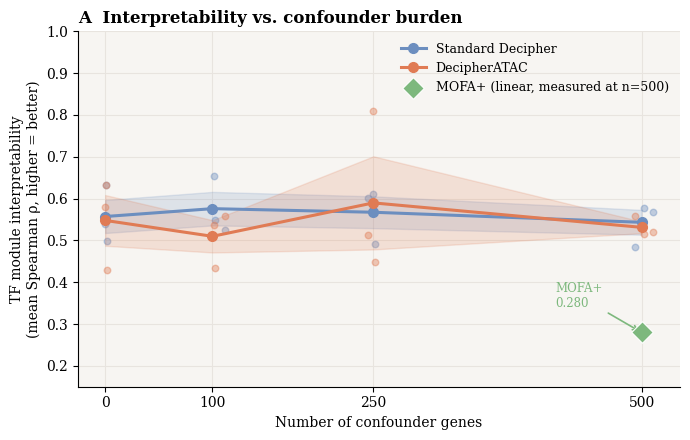

In [5]:
fig, ax = plt.subplots(figsize=(7, 4.5))

for key, color, label in [
    ('std',  C['std'],  'Standard Decipher'),
    ('atac', C['atac'], 'DecipherATAC'),
]:
    means = [stats[n][f'{key}_mean'] for n in N_CONF_LEVELS]
    errs  = [stats[n][f'{key}_err']  for n in N_CONF_LEVELS]
    ax.plot(N_CONF_LEVELS, means, 'o-', color=color, lw=2.2, ms=7,
            label=label, zorder=3)
    ax.fill_between(N_CONF_LEVELS,
                    [m-e for m,e in zip(means,errs)],
                    [m+e for m,e in zip(means,errs)],
                    color=color, alpha=0.18, zorder=2)
    # individual seed points
    rng = np.random.default_rng(99)
    for n in N_CONF_LEVELS:
        vals = stats[n][f'{key}_vals']
        jitter = rng.uniform(-12, 12, len(vals))
        ax.scatter(np.array([n]*len(vals)) + jitter, vals,
                   color=color, alpha=0.4, s=22, zorder=2)

# MOFA+ — shown as a single point, not a line, because it was only
# measured at one confounder level
if mofa['score'] is not None:
    ax.scatter([mofa['n_confounders']], [mofa['score']],
               color=C['mofa'], s=120, zorder=5, marker='D',
               label=f"MOFA+ (linear, measured at n={mofa['n_confounders']})",
               edgecolors='white', linewidth=0.8)
    ax.annotate(f"MOFA+\n{mofa['score']:.3f}",
                xy=(mofa['n_confounders'], mofa['score']),
                xytext=(mofa['n_confounders'] - 80, mofa['score'] + 0.06),
                fontsize=8.5, color=C['mofa'],
                arrowprops=dict(arrowstyle='->', color=C['mofa'], lw=1.2))

ax.set_xlabel('Number of confounder genes')
ax.set_ylabel('TF module interpretability\n(mean Spearman ρ, higher = better)')
ax.set_title('A  Interpretability vs. confounder burden',
             fontweight='bold', loc='left')
ax.set_xticks(N_CONF_LEVELS)
ax.set_ylim(0.15, 1.0)
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('benchmarks/results/panel_A_sweep.png', dpi=180, bbox_inches='tight')
plt.show()

## Panel B — Gain from ATAC prior (Δ per confounder level)

FileNotFoundError: [Errno 2] No such file or directory: 'benchmarks/results/panel_B_delta.png'

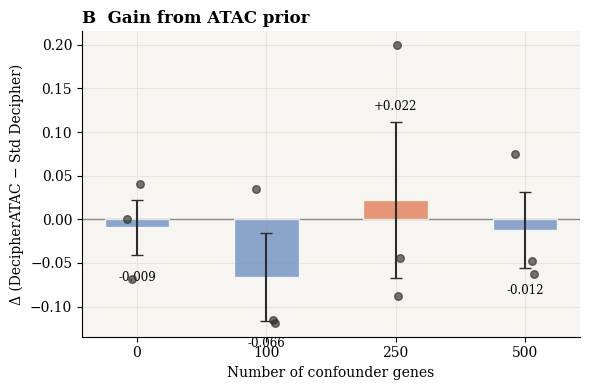

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))

xs     = np.arange(len(N_CONF_LEVELS))
means_d = [np.mean(deltas[n]) for n in N_CONF_LEVELS]
errs_d  = [np.std(deltas[n], ddof=1)/np.sqrt(len(deltas[n])) for n in N_CONF_LEVELS]

bar_colors = [C['atac'] if m > 0 else C['std'] for m in means_d]
ax.bar(xs, means_d, color=bar_colors, alpha=0.78, width=0.5,
       zorder=3, edgecolor='white')
ax.errorbar(xs, means_d, yerr=errs_d, fmt='none',
            color=C['text'], capsize=4, lw=1.5, zorder=4)

rng = np.random.default_rng(0)
for i, n in enumerate(N_CONF_LEVELS):
    jitter = rng.uniform(-0.08, 0.08, len(deltas[n]))
    ax.scatter(xs[i] + jitter, deltas[n],
               color=C['text'], alpha=0.65, s=30, zorder=5)

ax.axhline(0, color=C['text'], lw=1.0, alpha=0.5)
ax.set_xticks(xs)
ax.set_xticklabels([str(n) for n in N_CONF_LEVELS])
ax.set_xlabel('Number of confounder genes')
ax.set_ylabel('Δ (DecipherATAC − Std Decipher)')
ax.set_title('B  Gain from ATAC prior', fontweight='bold', loc='left')

for i, (m, e) in enumerate(zip(means_d, errs_d)):
    sign = '+' if m >= 0 else ''
    offset = e + 0.013 if m >= 0 else -(e + 0.030)
    ax.text(xs[i], m + offset, f'{sign}{m:.3f}', ha='center', fontsize=8.5)

plt.tight_layout()
plt.savefig('benchmarks/results/panel_B_delta.png', dpi=180, bbox_inches='tight')
plt.show()

## Panel C — Per-run scatter (each point = one seed × confounder condition)

/var/folders/1p/nrld7zb543xgvxqwdfjmbd_m0000gn/T/ipykernel_98005/4022022164.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('YlOrRd', len(N_CONF_LEVELS))


FileNotFoundError: [Errno 2] No such file or directory: 'benchmarks/results/panel_C_scatter.png'

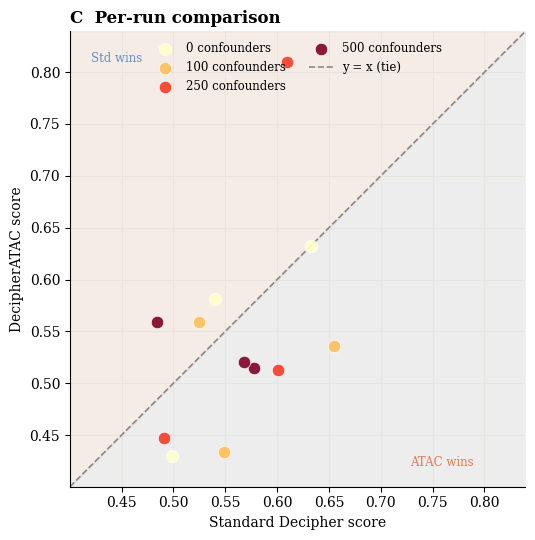

In [7]:
fig, ax = plt.subplots(figsize=(5.5, 5.5))

cmap = plt.cm.get_cmap('YlOrRd', len(N_CONF_LEVELS))
conf_colors = {n: cmap(i) for i, n in enumerate(N_CONF_LEVELS)}

for n in N_CONF_LEVELS:
    rows = [r for r in sweep if r['n_confounders'] == n]
    ax.scatter([r['std_score']  for r in rows],
               [r['atac_score'] for r in rows],
               color=conf_colors[n], s=80, zorder=4, alpha=0.9,
               label=f'{n} confounders', edgecolors='white', lw=0.5)

all_scores = [r['std_score'] for r in sweep] + [r['atac_score'] for r in sweep]
lo, hi = min(all_scores) - 0.03, max(all_scores) + 0.03
lim = [lo, hi]
ax.plot(lim, lim, '--', color=C['text'], lw=1.2, alpha=0.5, label='y = x (tie)')
ax.fill_between(lim, lim, [hi]*2, alpha=0.07, color=C['atac'])
ax.fill_between(lim, [lo]*2, lim, alpha=0.07, color=C['std'])
ax.text(hi - 0.05, lo + 0.02, 'ATAC wins', color=C['atac'], fontsize=8.5, ha='right')
ax.text(lo + 0.02, hi - 0.03, 'Std wins',  color=C['std'],  fontsize=8.5)

ax.set_xlim(*lim); ax.set_ylim(*lim); ax.set_aspect('equal')
ax.set_xlabel('Standard Decipher score')
ax.set_ylabel('DecipherATAC score')
ax.set_title('C  Per-run comparison', fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=8.5, ncol=2)
plt.tight_layout()
plt.savefig('benchmarks/results/panel_C_scatter.png', dpi=180, bbox_inches='tight')
plt.show()

## Panel D — Easy vs. hard setting (grouped bar, includes MOFA+)

In [ ]:
fig, ax = plt.subplots(figsize=(6.5, 4.5))

# Use first and last confounder levels
easy_n, hard_n = N_CONF_LEVELS[0], N_CONF_LEVELS[-1]
conditions  = [f'No confounders\n(n={easy_n})', f'High confounders\n(n={hard_n})']
conf_levels = [easy_n, hard_n]
x = np.arange(2)
width = 0.28

for (key, color, label), offset in [
    (('std',  C['std'],  'Std Decipher'),   -0.16),
    (('atac', C['atac'], 'DecipherATAC'),    0.16),
]:
    means = [stats[n][f'{key}_mean'] for n in conf_levels]
    errs  = [stats[n][f'{key}_err']  for n in conf_levels]
    ax.bar(x + offset, means, width, color=color, alpha=0.85,
           label=label, zorder=3, edgecolor='white')
    ax.errorbar(x + offset, means, yerr=errs, fmt='none',
                color=C['text'], capsize=3, lw=1.2, zorder=4)
    for i, (m, e) in enumerate(zip(means, errs)):
        ax.text(x[i]+offset, m+e+0.012, f'{m:.3f}', ha='center', fontsize=8)

# MOFA+ only at hard_n — single bar with hatch and annotation
if mofa['score'] is not None and mofa['n_confounders'] == hard_n:
    ax.bar(x[1] + 0.47, mofa['score'], width,
           color=C['mofa'], alpha=0.85, label='MOFA+ (linear)',
           zorder=3, edgecolor='white', hatch='//')
    ax.text(x[1]+0.47, mofa['score']+0.012, f"{mofa['score']:.3f}",
            ha='center', fontsize=8)
    ax.text(x[1]+0.47, -0.04,
            f"n={mofa['n_confounders']}\nonly",
            ha='center', fontsize=7, color=C['mofa'], style='italic')

ax.set_xticks(x)
ax.set_xticklabels(conditions)
ax.set_ylabel('TF module interpretability')
ax.set_ylim(0, min(1.0, max(stats[hard_n]['atac_mean'] + 0.2, 0.9)))
ax.set_title('D  Easy vs. hard setting', fontweight='bold', loc='left')
ax.legend(frameon=False, fontsize=9)
plt.tight_layout()
plt.savefig('benchmarks/results/panel_D_bars.png', dpi=180, bbox_inches='tight')
plt.show()

## Panel E — Summary table

In [ ]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')

headers = ['Confounders', 'Std Decipher (mean±SE)', 'DecipherATAC (mean±SE)',
           'Δ (ATAC−Std)', 'Winner']
rows = []
for n in N_CONF_LEVELS:
    s = stats[n]
    delta = s['atac_mean'] - s['std_mean']
    winner = 'ATAC ▲' if delta > 0.02 else ('Std ▲' if delta < -0.02 else '— Tie')
    rows.append([
        str(n),
        f"{s['std_mean']:.3f} ± {s['std_err']:.3f}",
        f"{s['atac_mean']:.3f} ± {s['atac_err']:.3f}",
        f"{delta:+.3f}",
        winner,
    ])

if mofa['score'] is not None:
    rows.append([f"MOFA+ baseline (n={mofa['n_confounders']})",
                 '—', f"{mofa['score']:.3f}", '—', '—'])

table = ax.table(cellText=rows, colLabels=headers,
                 loc='center', cellLoc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.1, 2.2)

for j in range(len(headers)):
    table[(0,j)].set_facecolor('#3C3C3C')
    table[(0,j)].set_text_props(color='white', fontweight='bold')

for i, row in enumerate(rows, 1):
    try:
        dv = float(row[3])
    except ValueError:
        dv = 0
    bg = '#FEF0EA' if dv > 0.02 else ('#EAF0FE' if dv < -0.02 else '#F7F5F2')
    for j in range(len(headers)):
        table[(i,j)].set_facecolor(bg)

ax.set_title('E  Summary table (mean ± SE across seeds)',
             fontweight='bold', loc='left', fontsize=11, pad=18)
plt.tight_layout()
plt.savefig('benchmarks/results/panel_E_table.png', dpi=180, bbox_inches='tight')
plt.show()

## Combined figure (all panels)

In [ ]:
fig = plt.figure(figsize=(16, 18))
gs  = gridspec.GridSpec(3, 2, figure=fig, hspace=0.52, wspace=0.38,
                        left=0.07, right=0.97, top=0.94, bottom=0.05)

axes = {
    'A': fig.add_subplot(gs[0, 0]),
    'B': fig.add_subplot(gs[0, 1]),
    'C': fig.add_subplot(gs[1, 0]),
    'D': fig.add_subplot(gs[1, 1]),
    'E': fig.add_subplot(gs[2, :]),
}

fig.text(0.5, 0.975, 'DecipherATAC — Benchmark Results',
         ha='center', fontsize=16, fontweight='bold')
fig.text(0.5, 0.963,
         f'3000 cells · 10 TF modules × 50 genes · tf_correlation=0.6  |  seeds {SEEDS}  |  {R["timestamp"][:10]}',
         ha='center', fontsize=8.5, color='#666')

# ── A ─────────────────────────────────────────────────────────────────────────
ax = axes['A']
rng = np.random.default_rng(99)
for key, color, label in [('std', C['std'], 'Standard Decipher'), ('atac', C['atac'], 'DecipherATAC')]:
    means = [stats[n][f'{key}_mean'] for n in N_CONF_LEVELS]
    errs  = [stats[n][f'{key}_err']  for n in N_CONF_LEVELS]
    ax.plot(N_CONF_LEVELS, means, 'o-', color=color, lw=2.2, ms=7, label=label, zorder=3)
    ax.fill_between(N_CONF_LEVELS, [m-e for m,e in zip(means,errs)],
                    [m+e for m,e in zip(means,errs)], color=color, alpha=0.18)
    for n in N_CONF_LEVELS:
        vals = stats[n][f'{key}_vals']
        ax.scatter(np.array([n]*len(vals)) + rng.uniform(-12, 12, len(vals)),
                   vals, color=color, alpha=0.4, s=20)
if mofa['score'] is not None:
    ax.scatter([mofa['n_confounders']], [mofa['score']], color=C['mofa'],
               s=120, zorder=5, marker='D',
               label=f"MOFA+ (n={mofa['n_confounders']} only)")
    ax.annotate(f"MOFA+\n{mofa['score']:.3f}",
                xy=(mofa['n_confounders'], mofa['score']),
                xytext=(mofa['n_confounders']-80, mofa['score']+0.07),
                fontsize=8, color=C['mofa'],
                arrowprops=dict(arrowstyle='->', color=C['mofa'], lw=1.0))
ax.set_xlabel('Number of confounder genes'); ax.set_ylabel('TF module interpretability\n(Spearman ρ)')
ax.set_title('A  Interpretability vs. confounder burden', fontweight='bold', loc='left', fontsize=11)
ax.set_xticks(N_CONF_LEVELS); ax.set_ylim(0.15, 1.0)
ax.legend(frameon=False, fontsize=9)

# ── B ─────────────────────────────────────────────────────────────────────────
ax = axes['B']
xs = np.arange(len(N_CONF_LEVELS))
md = [np.mean(deltas[n]) for n in N_CONF_LEVELS]
ed = [np.std(deltas[n], ddof=1)/np.sqrt(len(deltas[n])) for n in N_CONF_LEVELS]
ax.bar(xs, md, color=[C['atac'] if m>0 else C['std'] for m in md],
       alpha=0.78, width=0.5, zorder=3, edgecolor='white')
ax.errorbar(xs, md, yerr=ed, fmt='none', color=C['text'], capsize=4, lw=1.5)
rng2 = np.random.default_rng(0)
for i, n in enumerate(N_CONF_LEVELS):
    ax.scatter(xs[i] + rng2.uniform(-0.08, 0.08, len(deltas[n])),
               deltas[n], color=C['text'], alpha=0.65, s=28)
ax.axhline(0, color=C['text'], lw=1.0, alpha=0.5)
ax.set_xticks(xs); ax.set_xticklabels([str(n) for n in N_CONF_LEVELS])
ax.set_xlabel('Number of confounder genes'); ax.set_ylabel('Δ (ATAC − Std Decipher)')
ax.set_title('B  Gain from ATAC prior', fontweight='bold', loc='left', fontsize=11)
for i, (m, e) in enumerate(zip(md, ed)):
    ax.text(xs[i], m + (e+0.013 if m>=0 else -(e+0.030)),
            f"{'+'if m>=0 else ''}{m:.3f}", ha='center', fontsize=8.5)

# ── C ─────────────────────────────────────────────────────────────────────────
ax = axes['C']
cmap2 = plt.cm.get_cmap('YlOrRd', len(N_CONF_LEVELS))
cc = {n: cmap2(i) for i, n in enumerate(N_CONF_LEVELS)}
for n in N_CONF_LEVELS:
    rows = [r for r in sweep if r['n_confounders'] == n]
    ax.scatter([r['std_score'] for r in rows], [r['atac_score'] for r in rows],
               color=cc[n], s=80, zorder=4, alpha=0.9,
               label=f'{n} confounders', edgecolors='white', lw=0.5)
all_s = [r['std_score'] for r in sweep] + [r['atac_score'] for r in sweep]
lo2, hi2 = min(all_s)-0.03, max(all_s)+0.03
ax.plot([lo2,hi2],[lo2,hi2],'--',color=C['text'],lw=1.2,alpha=0.5,label='y=x')
ax.fill_between([lo2,hi2],[lo2,hi2],[hi2,hi2],alpha=0.07,color=C['atac'])
ax.fill_between([lo2,hi2],[lo2,lo2],[lo2,hi2],alpha=0.07,color=C['std'])
ax.set_xlim(lo2,hi2); ax.set_ylim(lo2,hi2); ax.set_aspect('equal')
ax.set_xlabel('Standard Decipher score'); ax.set_ylabel('DecipherATAC score')
ax.set_title('C  Per-run comparison', fontweight='bold', loc='left', fontsize=11)
ax.legend(frameon=False, fontsize=8, ncol=2)

# ── D ─────────────────────────────────────────────────────────────────────────
ax = axes['D']
easy_n, hard_n = N_CONF_LEVELS[0], N_CONF_LEVELS[-1]
x2 = np.arange(2)
for (key, color, label), offset in [(('std', C['std'], 'Std Decipher'), -0.16),
                                     (('atac', C['atac'], 'DecipherATAC'), 0.16)]:
    ms2 = [stats[n][f'{key}_mean'] for n in [easy_n, hard_n]]
    es2 = [stats[n][f'{key}_err']  for n in [easy_n, hard_n]]
    ax.bar(x2+offset, ms2, 0.28, color=color, alpha=0.85, label=label, edgecolor='white')
    ax.errorbar(x2+offset, ms2, yerr=es2, fmt='none', color=C['text'], capsize=3, lw=1.2)
    for i,(m,e) in enumerate(zip(ms2,es2)):
        ax.text(x2[i]+offset, m+e+0.01, f'{m:.3f}', ha='center', fontsize=7.5)
if mofa['score'] is not None and mofa['n_confounders'] == hard_n:
    ax.bar(x2[1]+0.47, mofa['score'], 0.28, color=C['mofa'], alpha=0.85,
           label='MOFA+ (linear)', edgecolor='white', hatch='//')
    ax.text(x2[1]+0.47, mofa['score']+0.01, f"{mofa['score']:.3f}", ha='center', fontsize=7.5)
ax.set_xticks(x2)
ax.set_xticklabels([f'No confounders\n(n={easy_n})', f'High confounders\n(n={hard_n})'])
ax.set_ylabel('TF module interpretability')
ax.set_ylim(0, 1.0)
ax.set_title('D  Easy vs. hard setting', fontweight='bold', loc='left', fontsize=11)
ax.legend(frameon=False, fontsize=9)

# ── E (table) ─────────────────────────────────────────────────────────────────
ax = axes['E']; ax.axis('off')
headers = ['Confounders', 'Std Decipher (mean±SE)', 'DecipherATAC (mean±SE)', 'Δ', 'Winner']
trows = []
for n in N_CONF_LEVELS:
    s = stats[n]; delta = s['atac_mean'] - s['std_mean']
    trows.append([str(n),
                  f"{s['std_mean']:.3f} ± {s['std_err']:.3f}",
                  f"{s['atac_mean']:.3f} ± {s['atac_err']:.3f}",
                  f"{delta:+.3f}",
                  'ATAC ▲' if delta>0.02 else ('Std ▲' if delta<-0.02 else '— Tie')])
if mofa['score'] is not None:
    trows.append([f"MOFA+ (n={mofa['n_confounders']})", '—', f"{mofa['score']:.3f}", '—', '—'])
t = ax.table(cellText=trows, colLabels=headers, loc='center', cellLoc='center')
t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1.1, 2.2)
for j in range(len(headers)):
    t[(0,j)].set_facecolor('#3C3C3C'); t[(0,j)].set_text_props(color='white', fontweight='bold')
for i, row in enumerate(trows, 1):
    try: dv = float(row[3])
    except: dv = 0
    bg = '#FEF0EA' if dv>0.02 else ('#EAF0FE' if dv<-0.02 else '#F7F5F2')
    for j in range(len(headers)): t[(i,j)].set_facecolor(bg)
ax.set_title('E  Summary table', fontweight='bold', loc='left', fontsize=11, pad=18)

plt.savefig('benchmarks/results/benchmark_all_panels.png', dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('Saved combined figure to benchmarks/results/benchmark_all_panels.png')